## Notebook for making figures 

In [2]:
from pathlib import Path
from datetime import datetime
from time import time

import numpy as np
import pandas as pd
import xarray as xr
import rioxarray as rxa
from rasterio.enums import Resampling
import matplotlib.pyplot as plt
import matplotlib.colors as pltcolors
from matplotlib.patches import Rectangle
import matplotlib.cm as cm
import geopandas as gpd
from shapely.geometry import MultiPoint, Polygon
from rasterio.plot import show as rioshow
# import contextily as ctx

from uavsar_pytools.convert.tiff_conversion import read_annotation
from uavsar_pytools.georeference import geolocate_uavsar

import sys
import os

scripts_dir = (os.path.dirname(os.getcwd()) + '/scripts/')
sys.path.append(scripts_dir)

from plotting import plot_tifs_grid, plot_coherence_matrix
from coherence import calc_coherence_unweighted, calc_coherence_matrix
from taus import decorrelation_temporal_model

/Users/julo9057/anaconda3/envs/snowex_uavsar_coherence/lib/python3.13/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)
/Users/julo9057/anaconda3/envs/snowex_uavsar_coherence/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/julo9057/anaconda3/envs/snowex_uavsar_coherence/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
data_dir = '../data/snowex_lowman/'
slc_dir = data_dir + 'slcs_geocoded/'
coh_dir = data_dir + 'coherences/'
tau_dir = data_dir + 'taus/'
snotel_dir = data_dir + 'snotel/'
qsi_dir = data_dir + 'snex_qsi_lidar/'
dem_dir = data_dir + 'dem_params/'

fig_dir = '../outputs/figures/insar_final_proj/'

In [4]:
# set the default style of the plots to the seaborn style
# print(plt.style.available)
plt.style.use('seaborn-v0_8')

### Background 

- ?

### Methods

- A map showing the UAVSAR flights, the Mores Creek Summit area, the location of the Snotel site
- The Mores Creek DEM with hillshading 
- The Vegetation height of Mores Creek 
- The location of the Snotel site 

In [5]:
# load one UAVSAR flight
uavsar_fp = slc_dir + 'lowman_05208_20002_006_200131_L090VV_01_BU_s2_2x8_geoslc.tif'
uavsar = rxa.open_rasterio(uavsar_fp, masked=True).squeeze()

# load Mores Creek DEM and resample
res = 5  # desired resolution in meters
dem_raw = rxa.open_rasterio(qsi_dir + 'SNEX20_QSI_DEM_0.5M_USIDMC_20210917_20210917.tif')
resampled_dem = dem_raw.rio.reproject(dem_raw.rio.crs, resampling=Resampling.average, resolution=(res, res))
dem = resampled_dem.rio.reproject(uavsar.rio.crs)
dem = dem.squeeze()  # remove band dimension
dem = dem.where(dem != dem.rio.nodata)  # set nodata values to NaN

# Snotel site 
snotel_site = (43.9333, -115.6667)

# load vegetation height data
veg_height = rxa.open_rasterio(qsi_dir + 'SNEX20_QSI_VH_0.5M_USIDMC_20200209_20200209.tif')
resampled_veg = veg_height.rio.reproject(veg_height.rio.crs, resampling=Resampling.average, resolution=(res, res))
veg = resampled_veg.rio.reproject(uavsar.rio.crs)
veg = veg.squeeze()  # remove band dimension
veg = veg.where(veg != veg.rio.nodata)  # set nodata values to NaN

# load basemap
basemap = rxa.open_rasterio("../data/snowex_lowman/basemap.tif")
basemap_reproj = basemap.rio.reproject(uavsar.rio.crs)

In [ ]:
# print bounds to verify
print(uavsar.rio.bounds())
print(basemap.rio.bounds())

(-115.92393493652344, 43.810691833496094, -115.36363220214844, 44.19214630126953)
(-116.0159683227539, 43.707850196720706, -115.31304361871052, 44.21395598363195)


In [ ]:
# get the outlines of valid data for UAVSAR and DEM
# import matplotlib.pyplot as plt
def valid_data_outline(da):
    arr = da.values
    if arr.ndim == 3:
        arr = arr[0, :, :]  # take first band if multi-band
    # Find valid (non-NaN) pixel indices
    valid = np.argwhere(~np.isnan(arr))
    if valid.shape[0] == 0:
        return None
    # Convert pixel indices to coordinates
    transform = da.rio.transform()
    coords = [transform * (col, row) for row, col in valid]
    # Compute convex hull of valid points
    hull = MultiPoint(coords).convex_hull
    return hull

uavsar_hull = valid_data_outline(uavsar)
dem_hull = valid_data_outline(dem)


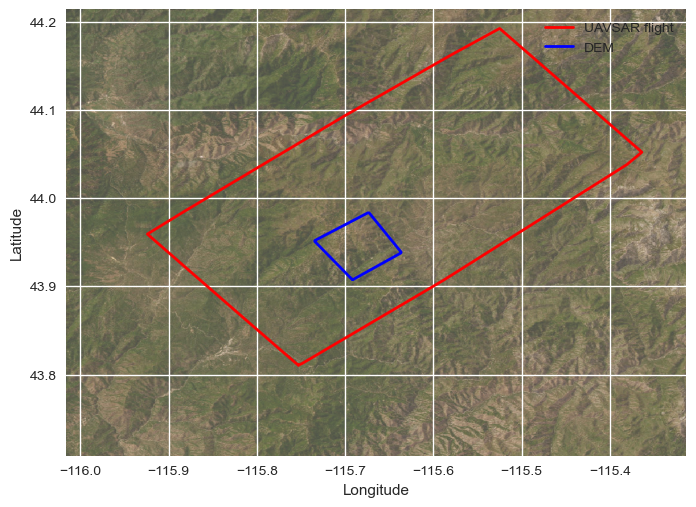

In [134]:
# plot the basemap and outlines. 

# Prepare array for imshow (assumes RGB or single-band)
arr = basemap_reproj.values
if arr.shape[0] >= 3:
    arr = arr[:3, :, :]  # Use first 3 bands for RGB
arr = arr.transpose(1, 2, 0) if arr.ndim == 3 else arr  # (bands, y, x) -> (y, x, bands) or (y, x)
extent = [
    basemap_reproj.x.values.min(), basemap_reproj.x.values.max(),
    basemap_reproj.y.values.min(), basemap_reproj.y.values.max()
 ]

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(arr, extent=extent, origin='upper', alpha=0.7)

# Overlay valid data outlines (assumes uavsar_hull and dem_hull already computed)
if uavsar_hull is not None:
    x, y = uavsar_hull.exterior.xy
    ax.plot(x, y, color='red', linewidth=2, label='UAVSAR flight')
if dem_hull is not None:
    x, y = dem_hull.exterior.xy
    ax.plot(x, y, color='blue', linewidth=2, label='DEM')

# boise = ax.plot(43.6150, -116.2023, marker='^', color='blue', linestyle='None', markersize=10, label='Boise')

# Set legend background to white and slightly transparent
legend = ax.legend()
ax.set_aspect('equal')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('')
plt.show()

# save figure
fig.savefig(fig_dir + 'data_extents.png', dpi=300)

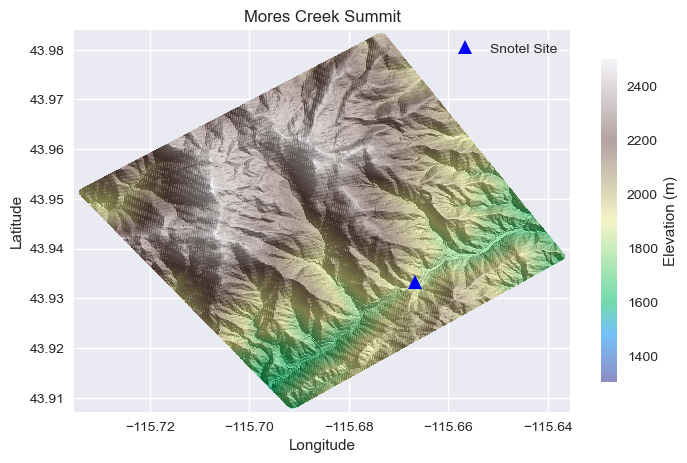

In [16]:
# plot hillshade and DEM 
from matplotlib.colors import LightSource

# create hillshade from DEM
ls = LightSource(azdeg=60, altdeg=60)
hillshade = ls.hillshade(dem.values, vert_exag=1)

# print(hillshade.shape)
dem_shade = dem.copy(data = hillshade)

# plot DEM with hillshading
# plt.style.use('light_background')
fig, ax = plt.subplots(figsize=(8, 6))
# ax = plt.gca() # Get current axes

# Plot hillshade as the base layer
hs = dem_shade.plot(ax=ax, cmap='gray', add_colorbar=False)
elev = dem.plot(ax=ax, cmap='terrain', vmin=1300, vmax=2500, add_colorbar=False, alpha=0.5) 
snotel = ax.plot(snotel_site[1], snotel_site[0], marker='^', color='blue', linestyle='None', markersize=10, label='Snotel Site')
ax.legend(frameon=False, loc='upper right')
ax.set_aspect('equal')
ax.grid(True)
ax.set_axisbelow(True)
# ax.set_facecolor('darkgray')

plt.title("Mores Creek Summit")
plt.colorbar(elev, alpha = 1, label="Elevation (m)", shrink=0.7)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

# save figure
fig.savefig(fig_dir + 'mores_creek_dem_hillshade.png', dpi=300)


In [ ]:
# map vegetation height

fig, ax = plt.subplots(figsize=(8, 6))
hs = dem_shade.plot(ax=ax, cmap='gray', add_colorbar=False)
veg_plot = veg.plot(ax=ax, cmap='Greens', vmin=0, vmax=30, add_colorbar=False, alpha=0.8)
snotel = ax.plot(snotel_site[1], snotel_site[0], marker='^', color='blue', linestyle='None', markersize=10, label='Snotel Site')
ax.legend(frameon=False, loc='upper right')
ax.set_aspect('equal')
ax.grid(True)
ax.set_axisbelow(True)

plt.title("Mores Creek Vegetation Height")
plt.colorbar(veg_plot, alpha = 1, label="Vegetation Height (m)", shrink=0.7)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

# save figure
fig.savefig(fig_dir + 'mores_creek_veg_height.png', dpi=300)

### Temporal coherence model 

- A plot showing what tau and gamma infinity correspond to 
- A histogram of fitted gamma infinities

### Results 

- Map of tau values 
- Principal components analysis using vegetation height, incidence angle

In [6]:
# load slope and aspect rasters
slope = rxa.open_rasterio(dem_dir + 'MCS_slope_5m.tif').squeeze()
aspect = rxa.open_rasterio(dem_dir + 'MCS_aspect_5m.tif').squeeze()

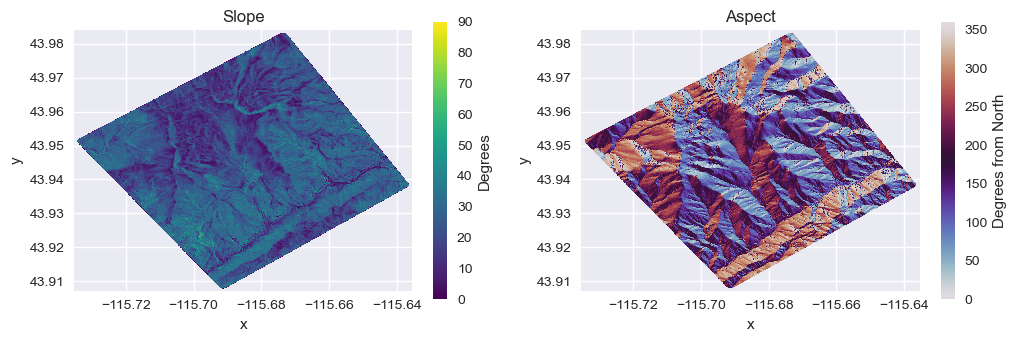

In [11]:
# plot slope and aspect
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
im = slope.plot(ax=ax1, vmin=0, vmax=90, cmap='viridis', add_colorbar=False)
ax1.set_title('Slope')
ax1.set_aspect('equal')
ax1.grid(True)
ax1.set_axisbelow(True)
fig.colorbar(im, ax=ax1, orientation='vertical', label='Degrees', shrink = 0.6)

im2 = aspect.plot(ax=ax2, cmap='twilight', vmin=0, vmax=360, add_colorbar=False)
ax2.set_title('Aspect')
ax2.set_aspect('equal')
ax2.grid(True)
ax2.set_axisbelow(True)
fig.colorbar(im2, ax=ax2, orientation='vertical', label='Degrees from North', shrink = 0.6)
plt.show()